In [1]:
%load_ext autoreload
%autoreload 2
import tensorflow as tf
import numpy as np
import gymnasium as gym

import jlab_opt_control.envs as custom_gym
import jlab_opt_control.agents as agents

import logging
run_openai_log = logging.getLogger("RunOpenAI")
run_openai_log.setLevel(logging.WARNING)
logging.basicConfig(format='%(asctime)s %(levelname)s:%(name)s:%(message)s')

In [2]:
 # Environment
env_id = 'DnC2s-Circle2D-Stateless-v0'
run_openai_log.info('Running env: {}'.format(env_id))

if env_id in gym.envs.registry:
    env = gym.make(env_id)
elif env_id in custom_gym.list_registered_modules():
    env = custom_gym.make(env_id)

num_states = env.observation_space.shape[0]
run_openai_log.info("Size of State Space ->  {}".format(num_states))
num_actions = env.action_space.shape[0]
run_openai_log.info("Size of Action Space ->  {}".format(num_actions))

upper_bound = env.action_space.high[0]
lower_bound = env.action_space.low[0]

run_openai_log.info("Max Value of Action ->  {}".format(upper_bound))
run_openai_log.info("Min Value of Action ->  {}".format(lower_bound))

2024-06-13 14:38:02,285 INFO:Circle2D-Env:############# Init Circle2D #############
2024-06-13 14:38:02,285 INFO:Circle2D-Env:Statefull: False
2024-06-13 14:38:02,286 INFO:Circle2D-Env:RDM Reset Mode: fixed
2024-06-13 14:38:02,286 INFO:Circle2D-Env:Action upper bound: [1. 1.]
2024-06-13 14:38:02,287 INFO:Circle2D-Env:Action lower bound: [-1. -1.]
2024-06-13 14:38:02,287 INFO:Circle2D-Env:State upper bound: [1. 1.]
2024-06-13 14:38:02,288 INFO:Circle2D-Env:State lower bound: [-1. -1.]
2024-06-13 14:38:02,288 INFO:Circle2D-Env:Target value: 0.95
2024-06-13 14:38:02,288 INFO:Circle2D-Env:Max episode steps: 1


{'DnC2s-Circle2D-Statefull-v0': <jlab_opt_control.envs.registration.EnvSpec object at 0x36cfd4520>, 'DnC2s-Circle2D-Stateless-v0': <jlab_opt_control.envs.registration.EnvSpec object at 0x11129c640>}
Attempting to load jlab_opt_control.envs with Circle2D


2024-06-13 14:38:30,488 ERROR:CfgLogger:Problem with key request using None
2024-06-13 14:38:30,494 INFO:Buffer:Buffer config saved successfully
2024-06-13 14:38:30,497 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:38:30,501 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:38:30,517 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:38:30,519 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:38:30,643 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:38:30,645 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number o

Attempting to load jlab_opt_control.agents with KerasTD3
Attempting to load jlab_opt_control.buffers with ER
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
epoch_19999
(50, 50) (50, 50) (2500, 1) (2500, 2)
(2500, 2)
(2500, 4) (2500, 1)
Q = -127.067 1 + 16.566 a0 + 91.080 a1 + 1244.536 a0^2 + 189.758 a0 a1 + 1285.001 a1^2 + -14.236 a0^3 + -84.509 a0^2 a1 + -29.290 a0 a1^2 + -124.017 a1^3 + -233.922 a0^4 + -118.538 a0^3 a1 + -1942.082 a0^2 a1^2 + -256.124 a0 a1^3 + -278.511 a1^4
(1, 70)
R2 score is 0.896


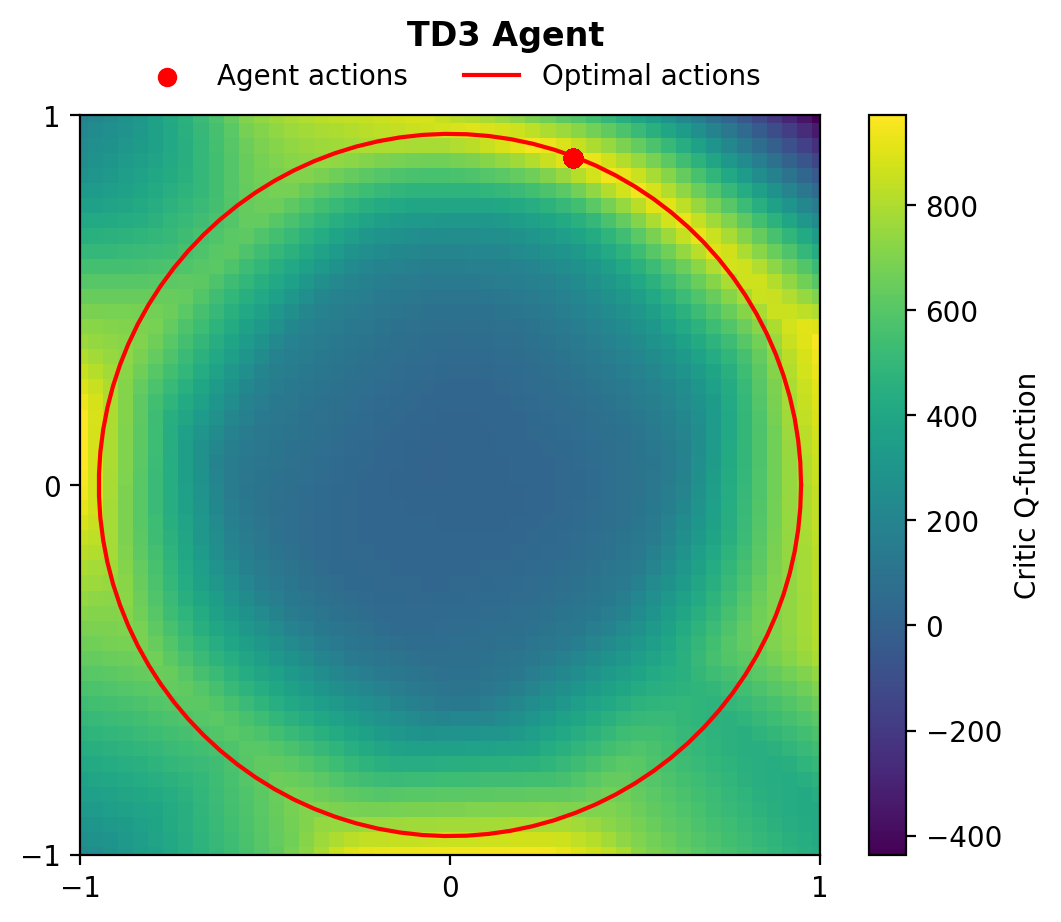

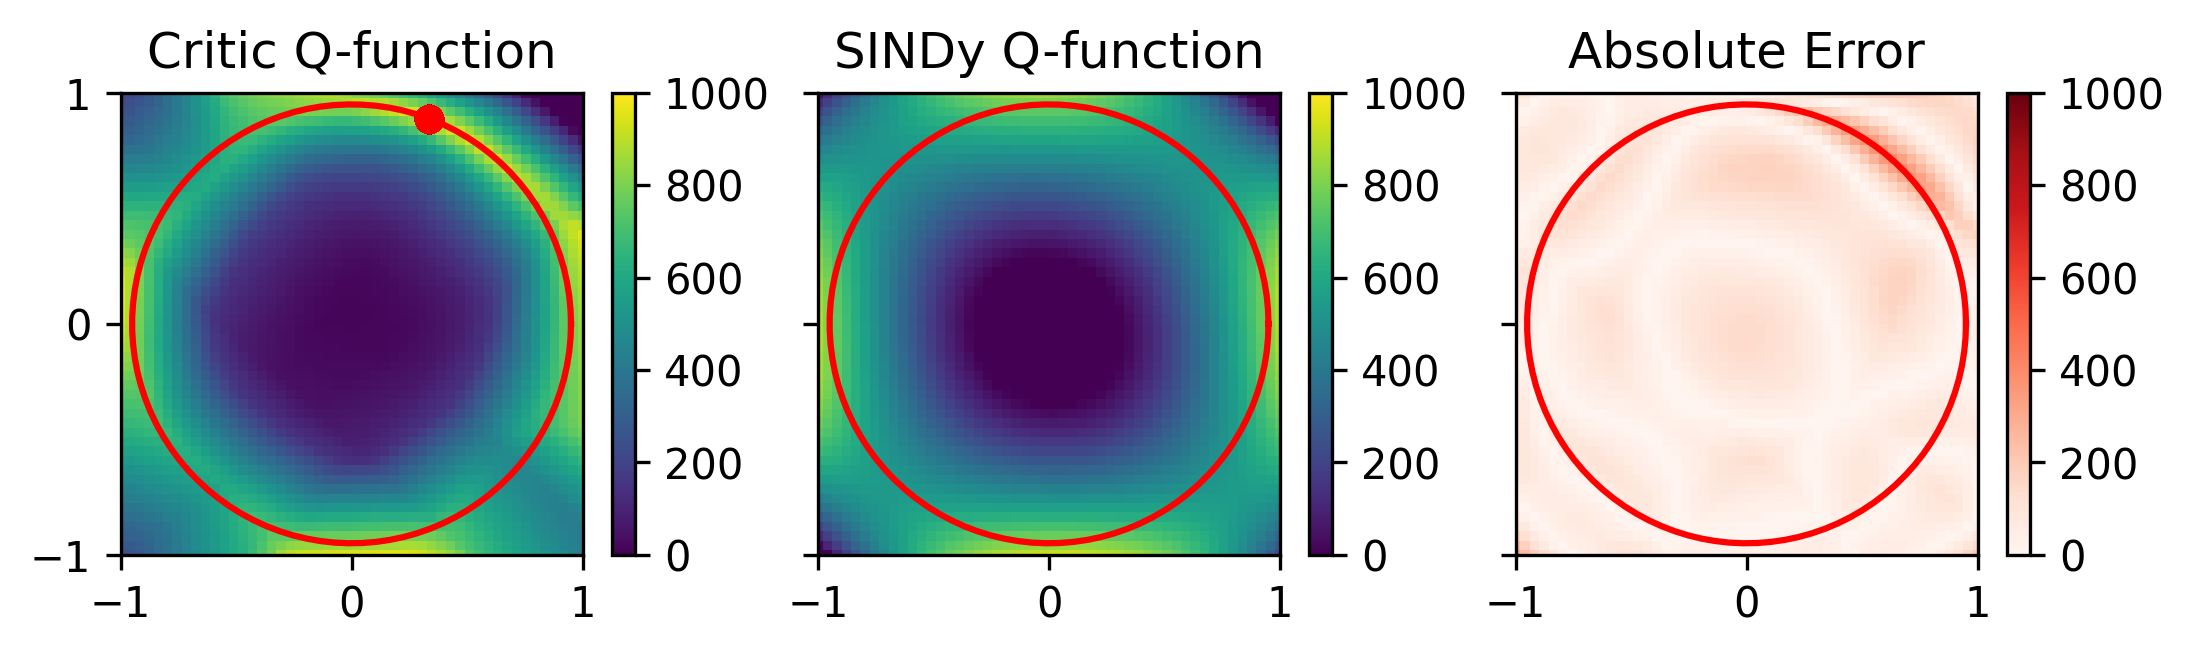

In [6]:
import os
import glob
import jlab_opt_control.agents as agents

logging.getLogger("Agent Registry").setLevel(logging.WARNING)
logging.getLogger("TD3-Agent").setLevel(logging.WARNING)

# Agent
agent_id = 'KerasTD3-v0'
logdir = glob.glob(f'./results/Circle/*{agent_id}*')[0]

buffer_type = 'ER-v0'
buffer_size = None

agent = agents.make(
    agent_id, 
    env=env, 
    logdir=logdir, 
    buffer_type=buffer_type, 
    buffer_size=buffer_size,
)

checkpoints = sorted(glob.glob(f'{logdir}/models/epoch_*'))
agent.model_load_path = checkpoints[-1]
print(os.path.basename(agent.model_load_path))
agent.load()

x = np.linspace(env.action_space.low[0], env.action_space.high[0])
y = np.linspace(env.action_space.low[1], env.action_space.high[1])

X, Y = np.meshgrid(x, y)
actions = np.stack([X, Y]).reshape(2, -1).T
states = np.zeros_like(actions)

critic_values = agent.critic_model1(states, actions, training=False).numpy()
actor_values = agent.actor_model(states, training=False)

print(X.shape, Y.shape, critic_values.shape, actor_values.shape)

# Plot action distribution
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, dpi=200)
im = ax.pcolormesh(X, Y, critic_values.reshape(X.shape), cmap='viridis')
ax.scatter(actor_values[:, 0], actor_values[:, 1], color='red', 
           label='Agent actions', zorder=10)

t = np.linspace(0, 2*np.pi, 100)
ax.plot(0.95*np.cos(t), 0.95*np.sin(t), color='red', 
        label='Optimal actions')

ax.set(xlim=[-1, 1], ylim=[-1, 1], 
       xticks=[-1, 0, 1], yticks=[-1, 0, 1],
       aspect='equal')
plt.colorbar(im, ax=ax, label='Critic Q-function')
ax.legend(loc='lower center', bbox_to_anchor=[0.5, 1],
          ncol=2, framealpha=0)
print(actor_values.shape)

fig.suptitle('TD3 Agent', fontweight='bold')

import pysindy as ps

inputs = np.concatenate([states, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

sindy = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=4),
    feature_names=['s0', 's1', 'a0', 'a1']
)
sindy.fit(x=inputs, x_dot=targets)
sindy.print(lhs='Q')
sindy_values = sindy.predict(inputs)
print(sindy.coefficients().shape)

print(f'R2 score is {sindy.score(x=inputs, x_dot=targets):.3f}')

# Plot action distribution
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(8.5, 2), dpi=300, sharex=True, sharey=True)
im = ax[0].pcolormesh(X, Y, critic_values.reshape(X.shape), cmap='viridis', vmin=0, vmax=1e3)
plt.colorbar(im, ax=ax[0])
ax[0].scatter(actor_values[:, 0], actor_values[:, 1], color='red', 
           label='Agent actions', zorder=10)
ax[0].set_title("Critic Q-function")

im = ax[1].pcolormesh(X, Y, sindy_values.reshape(X.shape), cmap='viridis', vmin=0, vmax=1e3)
plt.colorbar(im, ax=ax[1])
ax[1].set_title('SINDy Q-function')

im = ax[2].pcolormesh(X, Y, np.abs(critic_values - sindy_values).reshape(X.shape), cmap='Reds', vmin=0, vmax=1e3)
plt.colorbar(im, ax=ax[2])
ax[2].set_title('Absolute Error')

t = np.linspace(0, 2*np.pi, 100)
for a in ax:
    a.plot(0.95*np.cos(t), 0.95*np.sin(t), color='red', 
           label='Optimal actions')

    a.set(xlim=[-1, 1], ylim=[-1, 1], 
          xticks=[-1, 0, 1], yticks=[-1, 0, 1],
          aspect='equal')

2024-06-13 14:38:33,692 ERROR:CfgLogger:Problem with key request using None
2024-06-13 14:38:33,697 INFO:Buffer:Buffer config saved successfully
2024-06-13 14:38:33,699 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:38:33,702 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:38:33,715 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:38:33,718 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:38:33,843 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:38:33,847 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number o

Attempting to load jlab_opt_control.agents with KerasUncertaintyTD3
Attempting to load jlab_opt_control.buffers with ER
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with CriticUncertaintyFCNN
Attempting to load jlab_opt_control.models with CriticUncertaintyFCNN
Attempting to load jlab_opt_control.models with CriticUncertaintyFCNN
Attempting to load jlab_opt_control.models with CriticUncertaintyFCNN
epoch_19999


Text(0.5, 0.98, 'Uncertainty TD3 Agent')

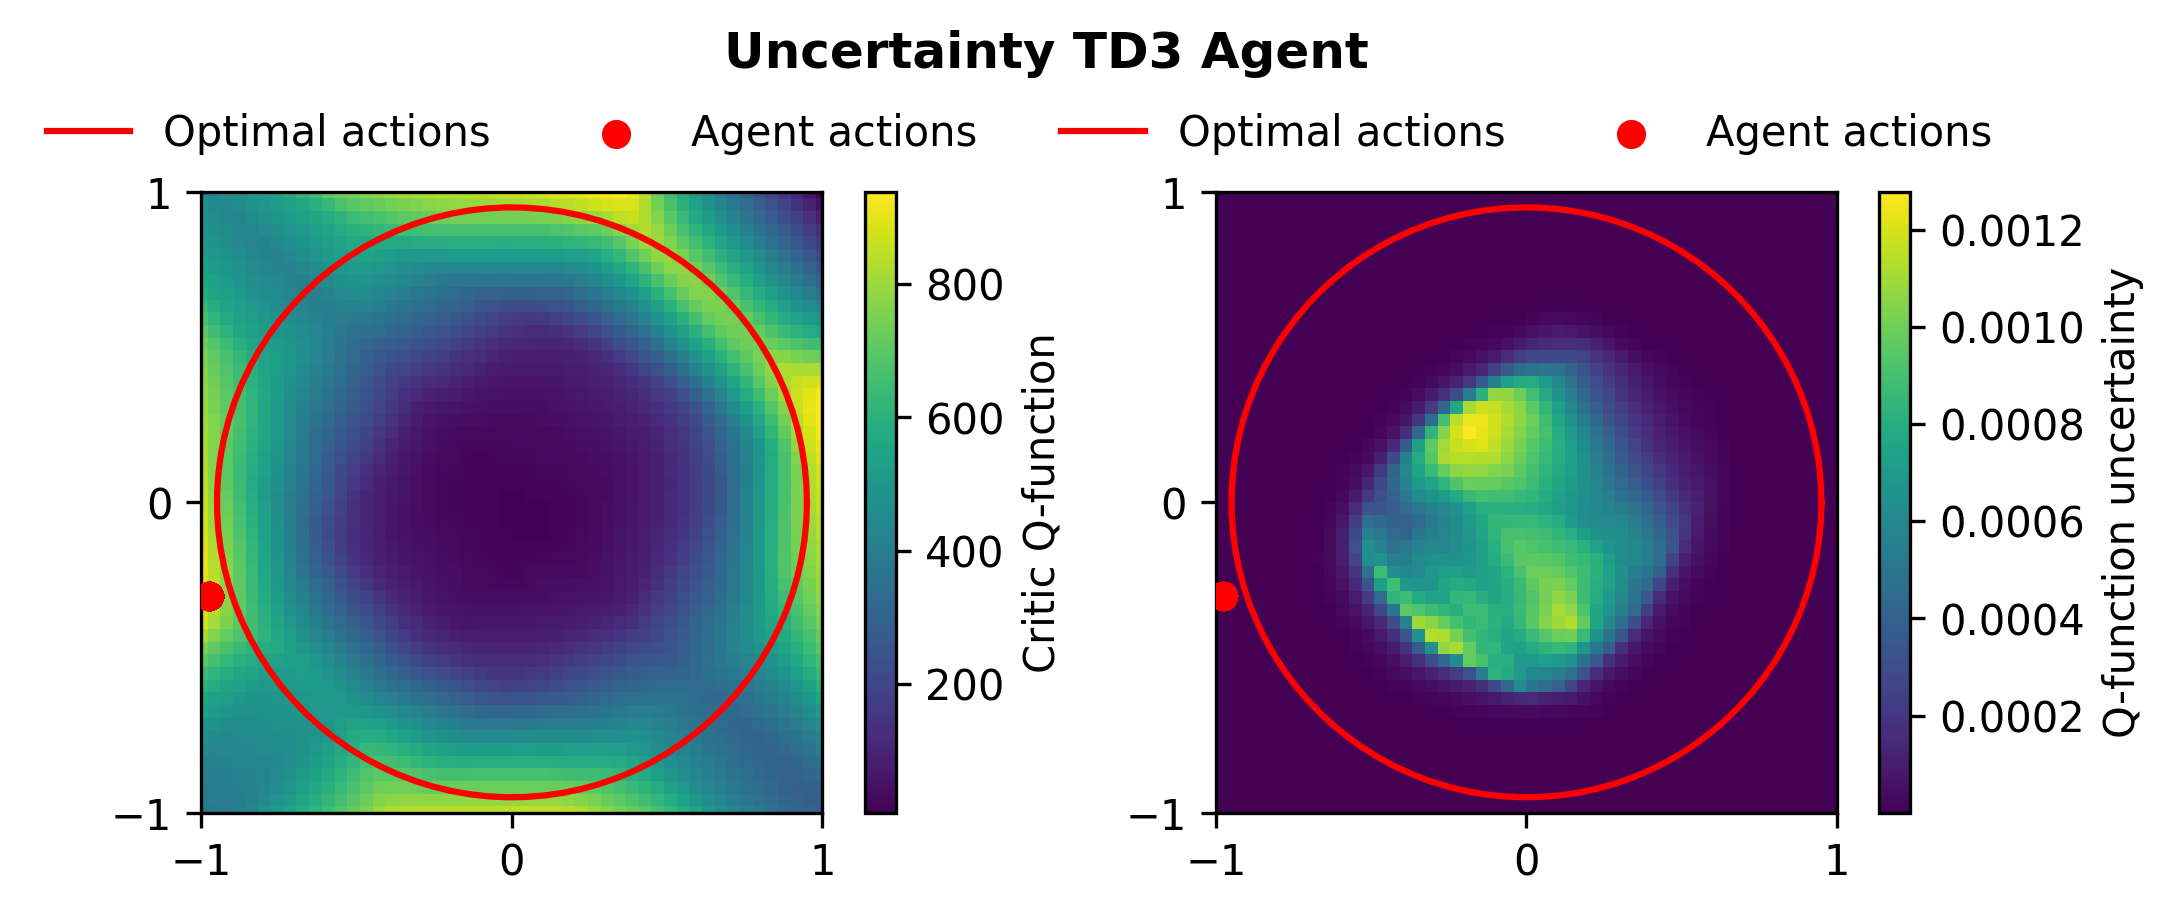

In [7]:
import os
import glob
import jlab_opt_control.agents as agents

logging.getLogger("Agent Registry").setLevel(logging.WARNING)
logging.getLogger("TD3-Agent").setLevel(logging.WARNING)

# Agent
agent_id = 'KerasUncertaintyTD3-v0'
logdir = glob.glob(f'./results/Circle/*{agent_id}*')[0]

buffer_type = 'ER-v0'
buffer_size = None

agent = agents.make(
    agent_id, 
    env=env, 
    logdir=logdir, 
    buffer_type=buffer_type, 
    buffer_size=buffer_size,
)

checkpoints = sorted(glob.glob(f'{logdir}/models/epoch_*'))
agent.model_load_path = checkpoints[-1]
print(os.path.basename(agent.model_load_path))
agent.load()

x = np.linspace(env.action_space.low[0], env.action_space.high[0])
y = np.linspace(env.action_space.low[1], env.action_space.high[1])

X, Y = np.meshgrid(x, y)
actions = np.stack([X, Y]).reshape(2, -1).T
states = np.zeros_like(actions)

states_actions = tf.keras.layers.Concatenate(axis=1)([states, actions])
actor_values = agent.actor_model(states, training=False)

# Plot action distribution
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, dpi=300, figsize=(8, 3))

critic_values, critic_logvar = agent.critic_model1(states, actions)
critic_values = critic_values.numpy().reshape(X.shape)
critic_logvar = critic_logvar.numpy().reshape(X.shape)

im = ax[0].pcolormesh(X, Y, critic_values,
                      alpha=1-np.exp(critic_logvar), 
                      cmap='viridis')#, vmin=-10, vmax=0)
plt.colorbar(im, ax=ax[0], label='Critic Q-function')

im = ax[1].pcolormesh(X, Y, np.exp(critic_logvar),
                      cmap='viridis')#, vmin=-10, vmax=0)
plt.colorbar(im, ax=ax[1], label='Q-function uncertainty')

for a in ax:
        t = np.linspace(0, 2*np.pi, 100)
        a.plot(0.95*np.cos(t), 0.95*np.sin(t), color='red', 
                label='Optimal actions')
        a.scatter(actor_values[:, 0], actor_values[:, 1], color='red',
                label='Agent actions', zorder=10)

        a.set(xlim=[-1, 1], ylim=[-1, 1], 
                xticks=[-1, 0, 1], yticks=[-1, 0, 1],
                aspect='equal')
        a.legend(loc='lower center', bbox_to_anchor=[0.5, 1],
                ncol=2, framealpha=0)

fig.subplots_adjust(top=0.8)
fig.suptitle('Uncertainty-Guided TD3 Agent', fontweight='bold')

2024-06-13 14:39:31,031 ERROR:CfgLogger:Problem with key request using None
2024-06-13 14:39:31,034 INFO:Buffer:Buffer config saved successfully
2024-06-13 14:39:31,036 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:39:31,040 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:39:31,056 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:39:31,059 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:39:31,182 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:39:31,185 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number o

Loading from KerasSINDyCriticTD3-v0
Attempting to load jlab_opt_control.agents with KerasSINDyCriticTD3
Attempting to load jlab_opt_control.buffers with ER
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with SINDyNetwork
Loading from checkpoint epoch_19999
Mean Absolute Error: 90.169, R2 score: 0.810


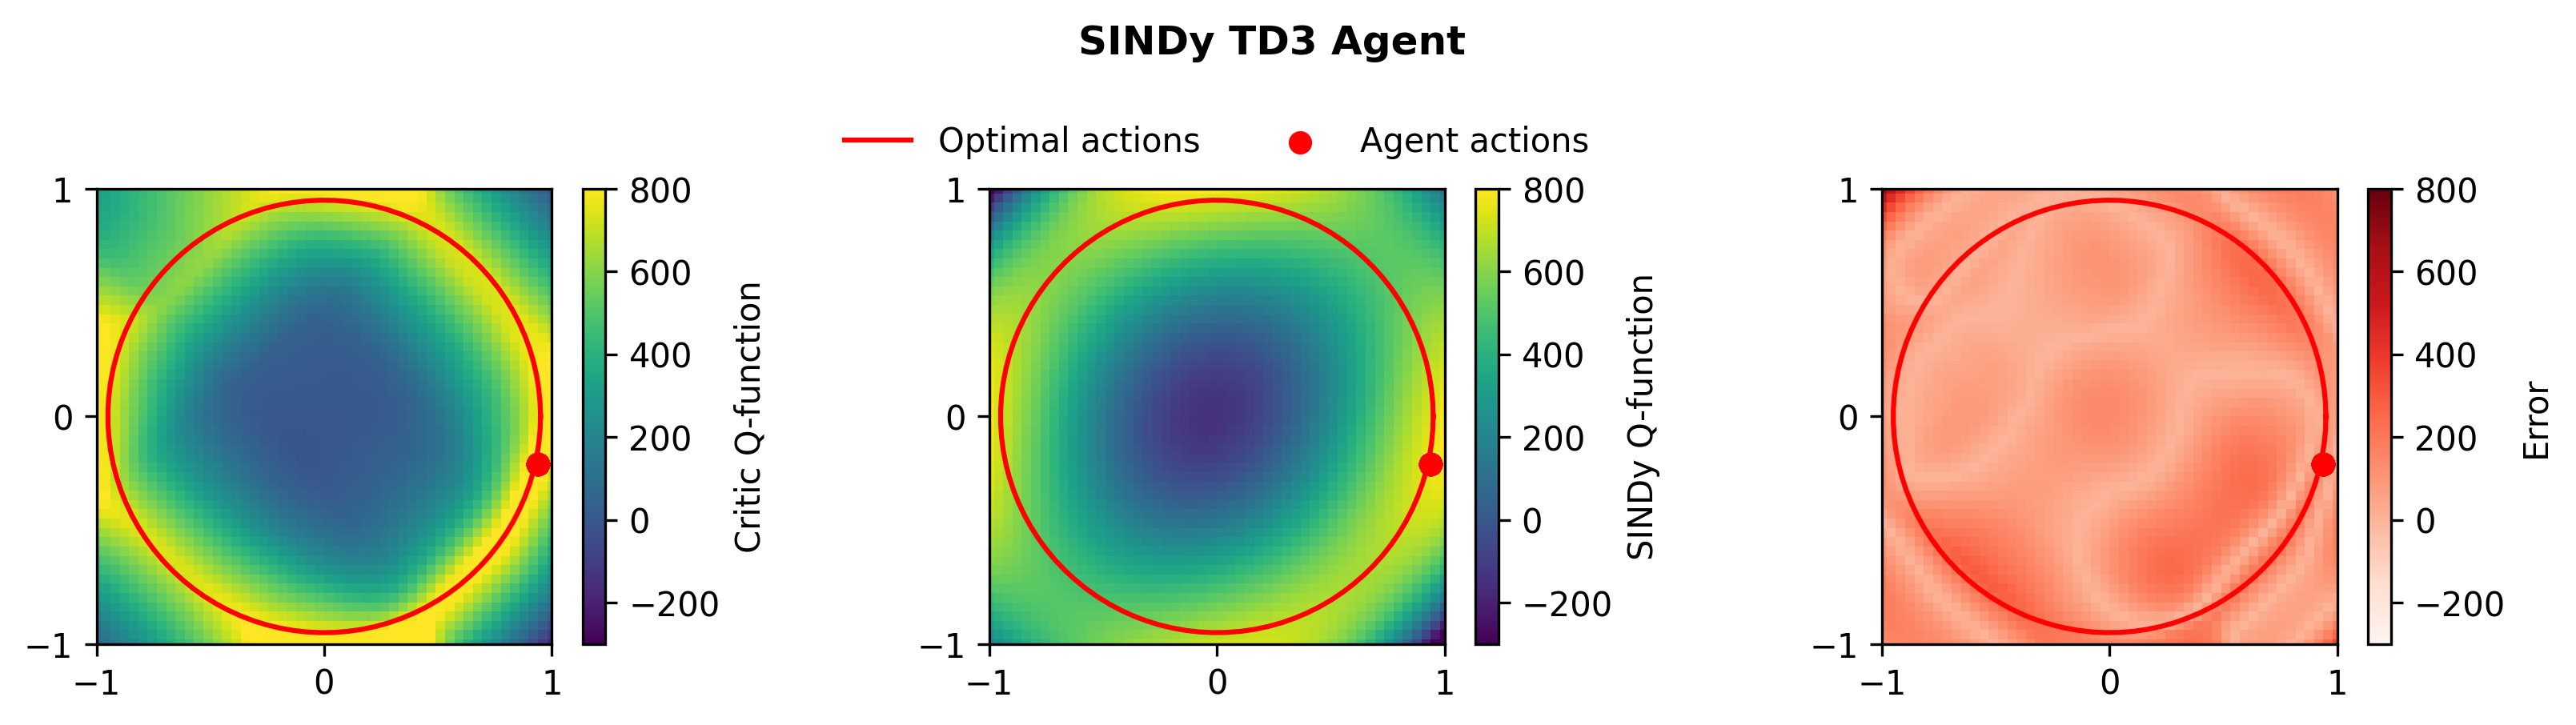

In [13]:
import os
import glob
import jlab_opt_control.agents as agents

logging.getLogger("Agent Registry").setLevel(logging.WARNING)
logging.getLogger("TD3-Agent").setLevel(logging.WARNING)

# Agent
agent_id = 'KerasSINDyCriticTD3-v0'
logdirs = sorted(glob.glob(f'./results/Circle/*{agent_id}*'))
logdir = logdirs[-1]
print(f'Loading from {os.path.basename(logdir)}')

buffer_type = 'ER-v0'
buffer_size = None

agent = agents.make(
    agent_id, 
    env=env, 
    logdir=logdir, 
    buffer_type=buffer_type, 
    buffer_size=buffer_size,
)

checkpoints = sorted(glob.glob(f'{logdir}/models/epoch_*'))
agent.model_load_path = checkpoints[-1]
print(f'Loading from checkpoint {os.path.basename(agent.model_load_path)}')
agent.load()

x = np.linspace(env.action_space.low[0], env.action_space.high[0])
y = np.linspace(env.action_space.low[1], env.action_space.high[1])

X, Y = np.meshgrid(x, y)
actions = np.stack([X, Y]).reshape(2, -1).T
states = np.zeros_like(actions)

states_actions = tf.keras.layers.Concatenate(axis=1)([states, actions])
lib_batch = agent.library(states_actions)
actor_values = agent.actor_model(states, training=False)

# Plot action distribution
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, dpi=300, figsize=(11, 3))

critic_values = agent.critic_model1(states, actions).numpy()
sindy_values = agent.critic_sindy(lib_batch).numpy()
error_values = np.abs(critic_values - sindy_values)

kwargs = dict(vmin=-300, vmax=800, cmap='viridis')
im = ax[0].pcolormesh(X, Y, critic_values.reshape(X.shape), **kwargs)
plt.colorbar(im, ax=ax[0], label='Critic Q-function')

im = ax[1].pcolormesh(X, Y, sindy_values.reshape(X.shape), **kwargs)
plt.colorbar(im, ax=ax[1], label='SINDy Q-function')

kwargs['cmap'] = 'Reds'
im = ax[2].pcolormesh(X, Y, error_values.reshape(X.shape), **kwargs)
plt.colorbar(im, ax=ax[2], label='Error')

from sklearn.metrics import r2_score
print(f'Mean Absolute Error: {np.mean(error_values):.3f}, R2 score: {r2_score(critic_values, sindy_values):.3f}')

for a in ax:
    t = np.linspace(0, 2*np.pi, 100)
    a.plot(0.95*np.cos(t), 0.95*np.sin(t), color='red', 
            label='Optimal actions')
    a.scatter(actor_values[:, 0], actor_values[:, 1], color='red',
              label='Agent actions', zorder=10)

    a.set(xlim=[-1, 1], ylim=[-1, 1], 
        xticks=[-1, 0, 1], yticks=[-1, 0, 1],
        aspect='equal')
ax[1].legend(loc='lower center', bbox_to_anchor=[0.5, 1],
        ncol=2, framealpha=0)

fig.subplots_adjust(top=0.8)
fig.suptitle('SINDy TD3 Agent', fontweight='bold')

plt.tight_layout()

2024-06-13 14:39:22,149 ERROR:CfgLogger:Problem with key request using None
2024-06-13 14:39:22,153 INFO:Buffer:Buffer config saved successfully
2024-06-13 14:39:22,155 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:39:22,157 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:39:22,173 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:39:22,175 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:39:22,299 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-13 14:39:22,302 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number o

Loading from index0_agent_KerasSINDyUncertaintyTD3-v0_env_DnC2s-Circle2D-Stateless-v0_date_20240613-143244
Attempting to load jlab_opt_control.agents with KerasSINDyUncertaintyTD3
Attempting to load jlab_opt_control.buffers with ER
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with SINDyNetwork
Loading from checkpoint epoch_19999
Mean Absolute Error: 103.291, R2 score: 0.824


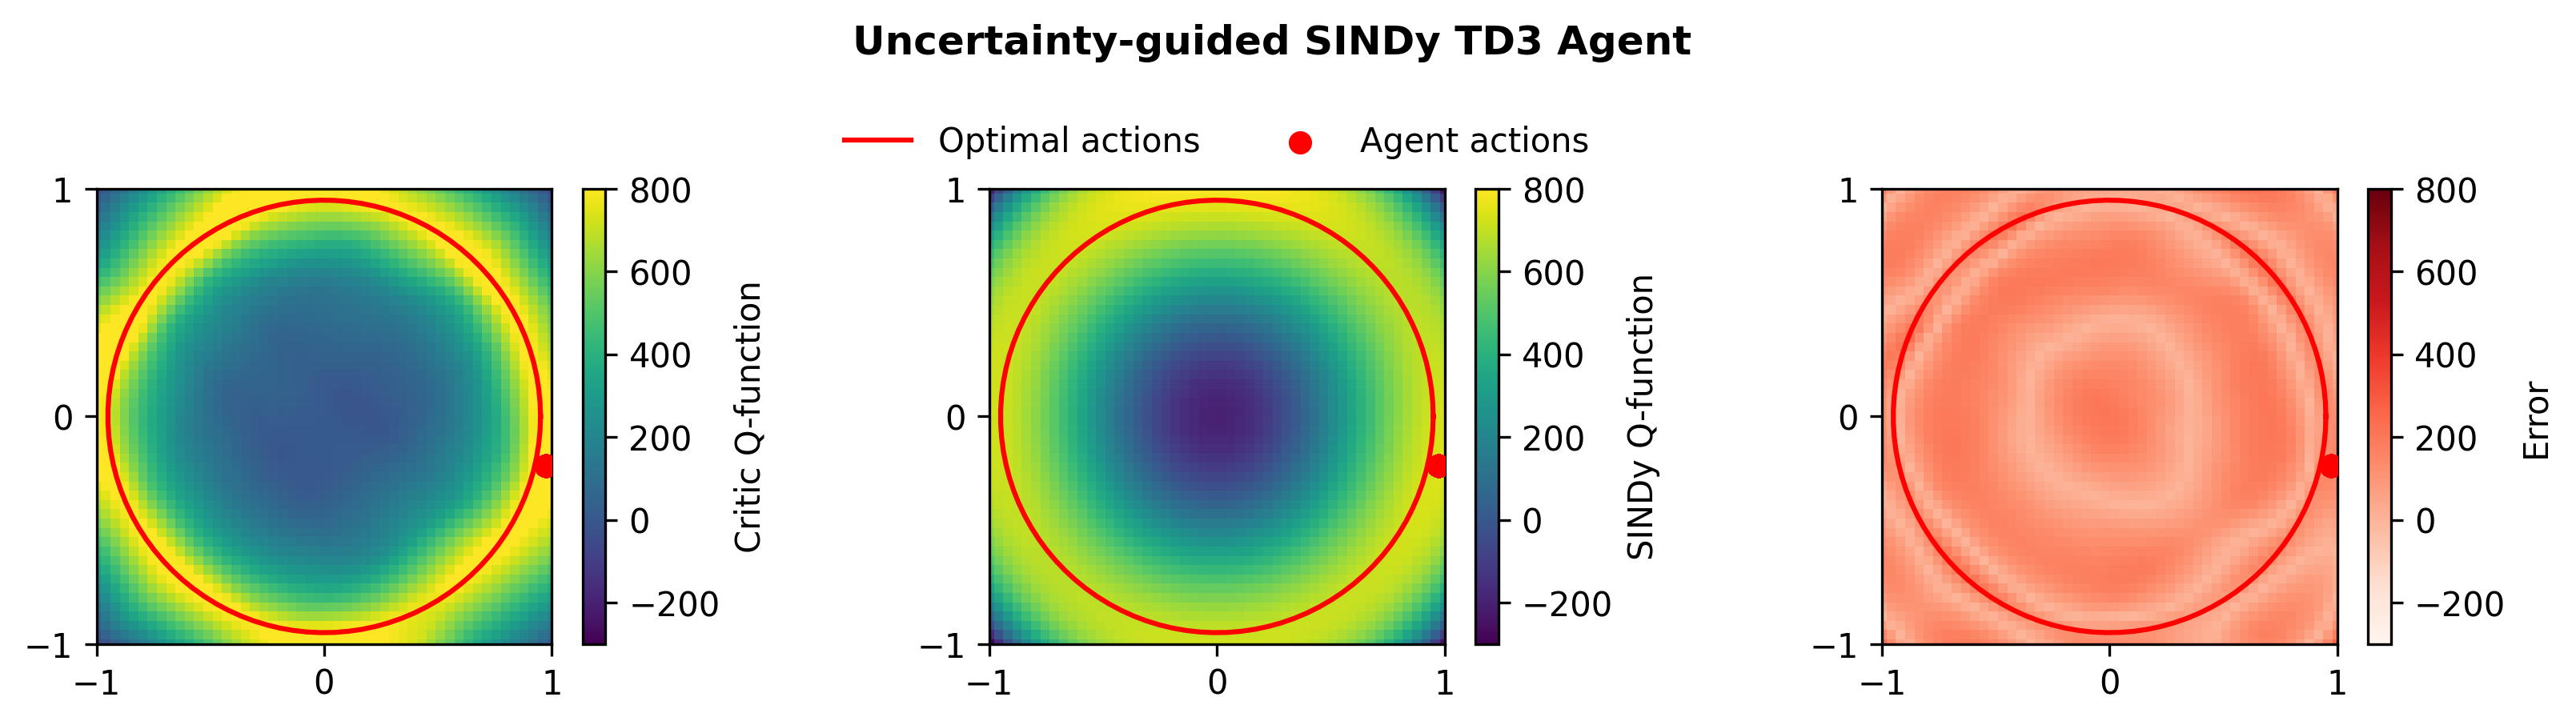

In [12]:
import os
import glob
import jlab_opt_control.agents as agents

logging.getLogger("Agent Registry").setLevel(logging.WARNING)
logging.getLogger("TD3-Agent").setLevel(logging.WARNING)

# Agent
agent_id = 'KerasSINDyUncertaintyTD3-v0'
logdirs = sorted(glob.glob(f'./results/Circle/*{agent_id}*'))
logdir = logdirs[-1]
print(f'Loading from {os.path.basename(logdir)}')

buffer_type = 'ER-v0'
buffer_size = None

agent = agents.make(
    agent_id, 
    env=env, 
    logdir=logdir, 
    buffer_type=buffer_type, 
    buffer_size=buffer_size,
)

checkpoints = sorted(glob.glob(f'{logdir}/models/epoch_*'))
agent.model_load_path = checkpoints[-1]
print(f'Loading from checkpoint {os.path.basename(agent.model_load_path)}')
agent.load()

x = np.linspace(env.action_space.low[0], env.action_space.high[0])
y = np.linspace(env.action_space.low[1], env.action_space.high[1])

X, Y = np.meshgrid(x, y)
actions = np.stack([X, Y]).reshape(2, -1).T
states = np.zeros_like(actions)

states_actions = tf.keras.layers.Concatenate(axis=1)([states, actions])
lib_batch = agent.library(states_actions)
actor_values = agent.actor_model(states, training=False)

# Plot action distribution
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, dpi=300, figsize=(11, 3))

critic_values = agent.critic_model1(states, actions).numpy()
sindy_values = agent.critic_sindy(lib_batch).numpy()
error_values = np.abs(critic_values - sindy_values)

kwargs = dict(vmin=-300, vmax=800, cmap='viridis')
im = ax[0].pcolormesh(X, Y, critic_values.reshape(X.shape), **kwargs)
plt.colorbar(im, ax=ax[0], label='Critic Q-function')

im = ax[1].pcolormesh(X, Y, sindy_values.reshape(X.shape), **kwargs)
plt.colorbar(im, ax=ax[1], label='SINDy Q-function')

kwargs['cmap'] = 'Reds'
im = ax[2].pcolormesh(X, Y, error_values.reshape(X.shape), **kwargs)
plt.colorbar(im, ax=ax[2], label='Error')

from sklearn.metrics import r2_score
print(f'Mean Absolute Error: {np.mean(error_values):.3f}, R2 score: {r2_score(critic_values, sindy_values):.3f}')

for a in ax:
    t = np.linspace(0, 2*np.pi, 100)
    a.plot(0.95*np.cos(t), 0.95*np.sin(t), color='red', 
            label='Optimal actions')
    a.scatter(actor_values[:, 0], actor_values[:, 1], color='red',
              label='Agent actions', zorder=10)

    a.set(xlim=[-1, 1], ylim=[-1, 1], 
        xticks=[-1, 0, 1], yticks=[-1, 0, 1],
        aspect='equal')
ax[1].legend(loc='lower center', bbox_to_anchor=[0.5, 1],
        ncol=2, framealpha=0)

fig.subplots_adjust(top=0.8)
fig.suptitle('Uncertainty-guided SINDy TD3 Agent', fontweight='bold')

plt.tight_layout()